In [7]:
import kagglehub

# Download latest version
pathh = kagglehub.dataset_download("l3llff/flowers")

print("Path to dataset files:", pathh)

Path to dataset files: C:\Users\Chakkaphan\.cache\kagglehub\datasets\l3llff\flowers\versions\4


#### Teacher Model

In [8]:
import shutil
import os

import splitfolders

import cv2

import torch
import torch.nn as nn
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary
from torch.utils.tensorboard import SummaryWriter

import torchvision
from torchvision import datasets
from torchvision.transforms import v2
from torchvision.ops import Conv2dNormActivation

from dataclasses import dataclass
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sn

import matplotlib.pyplot as plt
import time
import numpy as np
import random
import warnings
from tqdm import tqdm

import pandas as pd

%matplotlib inline
warnings.filterwarnings("ignore")

In [9]:
dataset = pathh + "/flowers/"
classes = os.listdir(dataset)
print(classes)

['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'daffodil', 'dandelion', 'iris', 'magnolia', 'rose', 'sunflower', 'tulip', 'water_lily']


##### dataset visualization

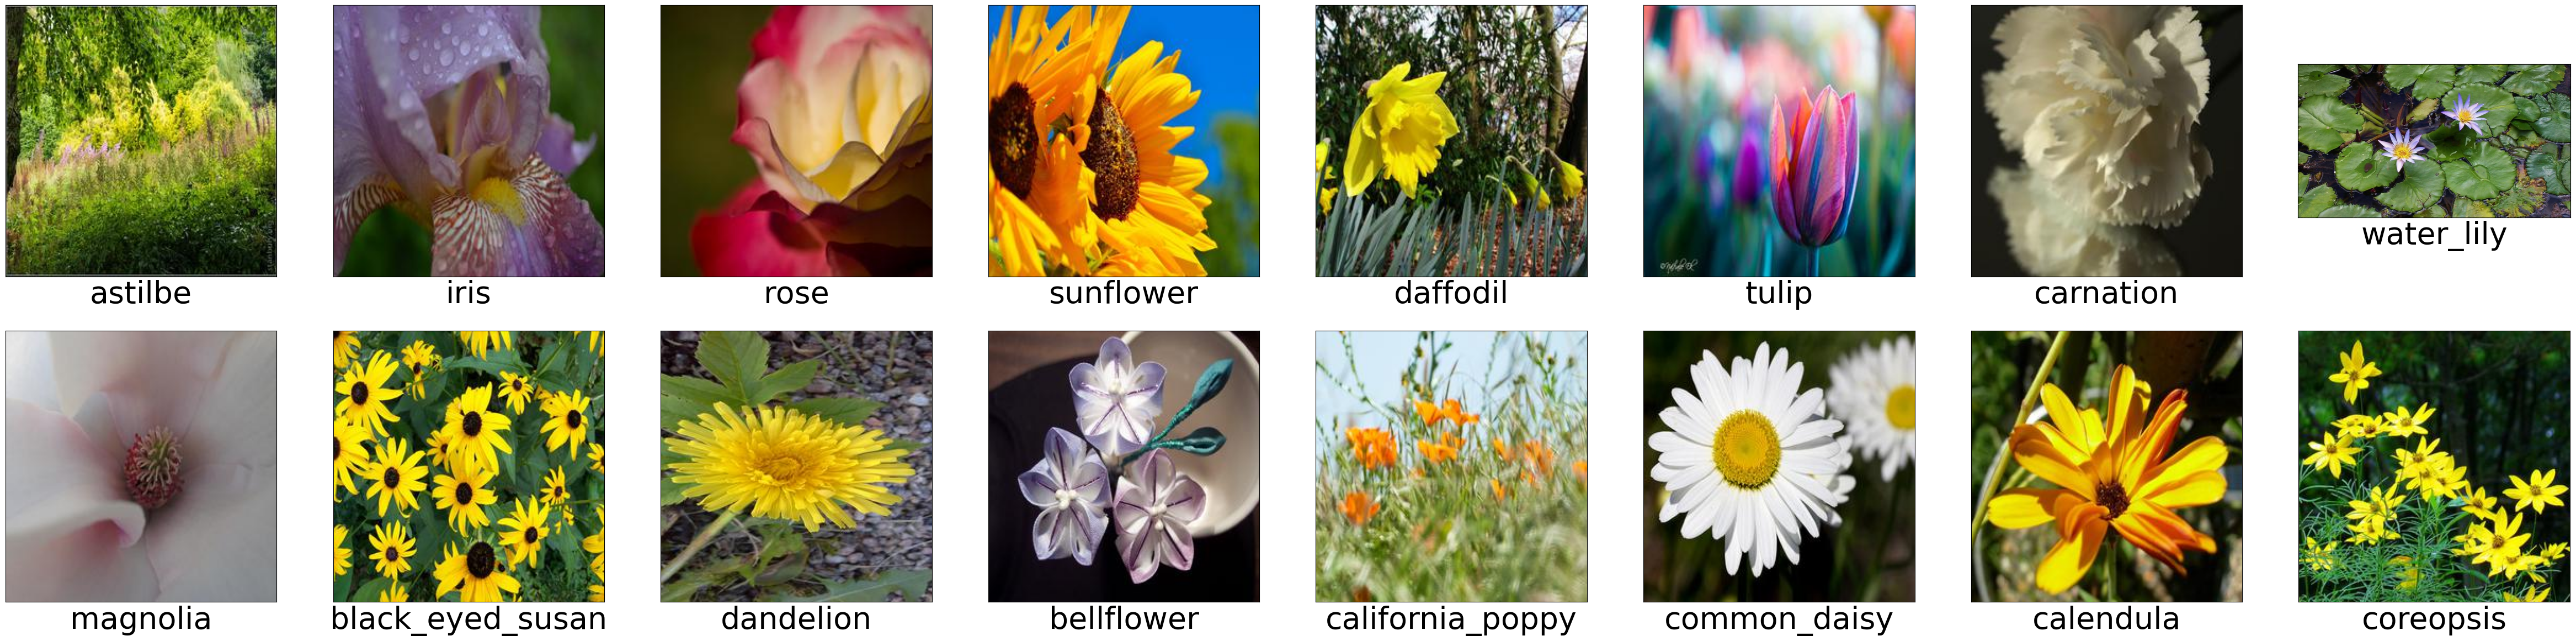

In [5]:
num_classes = len(classes)
#print(num_classes)
classes = set(classes)
class_images_len = {}
plt.figure(figsize=(60,60), dpi=100)
for i, flower_class in enumerate(classes):
    # Collect the number of images for classes
    image_filenames = os.listdir(dataset + flower_class)
    images_len = len(image_filenames)
    class_images_len[flower_class] = images_len

    # Plot the images about the classes
    i+=1
    image_i = plt.imread(dataset + flower_class + "/" + image_filenames[0] )
    plt.subplot(8,8,i, xticks = [], yticks = [])
    plt.imshow(image_i)
    plt.xlabel(flower_class, fontsize=40)

plt.show()

In [ ]:
# Sort the number of images for classes
sorted_class_images_len = {k: v for k, v in sorted(class_images_len.items(), key=lambda item: item[1], reverse=True)}

# Barplot for number of images for classes
fig2, ax2 = plt.subplots(figsize=(10, 7))
sn.barplot(x=list(sorted_class_images_len.keys()), y=list(sorted_class_images_len.values()), 
           ax=ax2, palette="flare", orientation='vertical')

ax2.tick_params(axis='x', labelrotation=90, labelsize=10)
ax2.bar_label(ax2.containers[0], label_type='edge')
plt.title("Number of images of the flower classes\nNumber of Classes: "+str(num_classes))
plt.show()

##### check image size

In [ ]:
# Check to size of the pictures, because it seems to be different for water_lily
# (256, 256, 3)
different_img_size_class = False
different_img_size_classes = {}
for i, flower_class in enumerate(classes):
    # Collect the number of images for classes
    image_filenames = os.listdir(dataset + flower_class)
    image_sizes = {}
    different_img_size_class = False
    
    for image_filename in image_filenames:
        img = cv2.imread(dataset + flower_class + "/" + image_filename)

        if img.shape != (256, 256, 3):
            different_img_size_class = True
            image_sizes[str(img.shape)] = image_sizes.get(str(img.shape), 0) + 1
            
    if different_img_size_class: 
        print(flower_class)
        different_img_size_classes[flower_class] = image_sizes

#### Config

In [15]:
@dataclass(frozen=True)
class TrainingConfig:
        batch_size: int = 32
        num_epochs: int = 80
        learning_rate: float = 0.0001

        log_interval: int = 1
        test_interval: int = 1
        num_workers: int = 1
        device: str = "cuda"

train_config = TrainingConfig()
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print("Available Device: ", DEVICE)

Available Device:  cuda


#### Seed

In [16]:
'''
Completely reproducible results are not guaranteed across PyTorch releases, individual commits, or different platforms. 
Furthermore, results may not be reproducible between CPU and GPU executions, even when using identical seeds.
Set seed to control sources of randomness that can cause multiple executions of your application to behave differently. 
'''
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True

set_seed(42)
splitfolders_seed = 1337

#### Train, Validation, Test data

In [17]:
# If your datasets is balanced (each class has the same number of samples) and enough big, choose ratio otherwise fixed
# images will be shuffled
outputFolder = "flowers/"
splitfolders.fixed(input=dataset, output=outputFolder, 
                    seed=splitfolders_seed, fixed=(100, 100), oversample=False, group_prefix=None, move=False)

Copying files: 15740 files [00:10, 1449.09 files/s]


In [13]:
train_root = outputFolder + "train/"
valid_root = outputFolder + "val/"
test_root = outputFolder + "test/"

#### Transformations

In [18]:
img_size = (256, 256)
preprocess = v2.Compose([v2.Resize(img_size, antialias=True), v2.ToTensor()])

train_data = datasets.ImageFolder(root=train_root, transform = preprocess)
train_data[0][0].shape

train_loader = DataLoader(train_data, shuffle = True, batch_size = 32, num_workers = train_config.num_workers)

In [19]:
mean = torch.tensor([0.4495, 0.4046, 0.2721])
std = torch.tensor([0.3005, 0.2555, 0.2738])

In [20]:
common_transforms = v2.Compose([preprocess, v2.Normalize(mean=mean,std=std)])

train_transforms = v2.Compose(
    [
        preprocess,
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomResizedCrop(size=(224, 224), antialias=True),
        v2.RandomApply(
            [v2.RandomAffine(degrees=(30, 70), translate=(0.1, 0.3), scale=(0.5, 0.75)),]
            , p =0.1),
        v2.Normalize(mean = mean,std = std)
    ]
)

In [21]:
#Augmentation to training dataset
train_data = datasets.ImageFolder(root = train_root, transform = train_transforms)

# The validation, test dataset should not be augmentated, just use common transforms like Resize, ToTensor, Normalize
val_data = datasets.ImageFolder(root=valid_root, transform = common_transforms)
test_data = datasets.ImageFolder(root=test_root, transform = common_transforms)

In [22]:
train_loader = DataLoader(train_data, shuffle = True, batch_size = 32)
val_loader = DataLoader(val_data, shuffle = False, batch_size = 16)
test_loader = DataLoader(test_data, shuffle = False, batch_size = 16)

In [23]:
class CNN_model(nn.Module):
  def __init__(self):
    super().__init__()

    self._model = nn.Sequential(

        # Conv1
        # norm_layer default: torch.nn.BatchNorm2d
        Conv2dNormActivation(in_channels = 3, out_channels=32, kernel_size = 5, activation_layer=nn.SiLU),
        Conv2dNormActivation(in_channels = 32, out_channels=32, kernel_size = 3, activation_layer=nn.SiLU),
        nn.MaxPool2d(kernel_size = 2),

        # Conv2
        Conv2dNormActivation(in_channels = 32, out_channels=64, kernel_size = 3, activation_layer=nn.SiLU),
        Conv2dNormActivation(in_channels = 64, out_channels=128, kernel_size = 3, activation_layer=nn.SiLU),
        nn.MaxPool2d(kernel_size = 2),

        # Conv3
        Conv2dNormActivation(in_channels = 128, out_channels=256, kernel_size = 3, activation_layer=nn.SiLU),
        Conv2dNormActivation(in_channels = 256, out_channels=256, kernel_size = 3, activation_layer=nn.SiLU),
        nn.MaxPool2d(kernel_size = 2),

        Conv2dNormActivation(in_channels = 256, out_channels=512, kernel_size = 3, activation_layer=nn.SiLU),
        nn.MaxPool2d(kernel_size = 2),

        # Feed Forward Layers 
        nn.AdaptiveAvgPool2d(output_size=(3,3)),

        # Flatten the convolutional features.
        nn.Flatten(),

        # Classifier
        nn.Linear(in_features = 512*3*3, out_features = 256),
        nn.Linear(in_features = 256, out_features = num_classes)
    )

  def forward(self,x):
      return self._model(x)

In [24]:
model = CNN_model()

optimizer  = Adam(model.parameters(), lr = train_config.learning_rate)
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"
writer = SummaryWriter()

#### Training

In [19]:
def train(model, train_loader):
    model.train()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_train_samples = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        # Zero gradients for every batch!
        optimizer.zero_grad()
        # forward
        outputs = model(images)

        # Compute the loss and its gradients
        # F.cross_entropy combines the LogSoftmax and NLLLoss
        loss = F.cross_entropy(outputs, labels)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, dim=1)
        total_train_samples += labels.shape[0]
        correct_predictions += (predicted == labels).sum().item()

    train_avg_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_predictions / total_train_samples
    return train_avg_loss, train_accuracy

In [20]:
def validation(model, val_loader):
    model.eval()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_val_samples = 0

    for images, labels in tqdm(val_loader, desc="Validation"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # disable gradient calculation and tracking, so only forward pass 
        # no need to update the model's weights, so there is no need to compute gradients
        with torch.no_grad():
             outputs = model(images)

        loss = F.cross_entropy(outputs, labels)
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, dim=1)
        total_val_samples += labels.shape[0]
        correct_predictions += (predicted == labels).sum().item()

    val_avg_loss = running_loss / len(val_loader)
    val_accuracy = 100 * correct_predictions / total_val_samples
    return val_avg_loss, val_accuracy

In [21]:
def main(model, train_loader, val_loader):

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_acc = 0.0
    best_weights = None
    best_epoch = 0
    best_model_val_loss = 0
    
    for epoch in range(train_config.num_epochs):
        print("Epoch: ", epoch+1, " /", train_config.num_epochs)
        train_loss, train_accuracy = train(model, train_loader)
        val_loss, val_accuracy = validation(model, val_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        
        # Logging metrics to tensorboard
        writer.add_scalar('Training Loss', train_loss)
        writer.add_scalar('Validation Loss', val_loss)
        writer.add_scalar('Training Accuracy', train_accuracy)
        writer.add_scalar('Validation accuracy', val_accuracy)

        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            best_weights =  model.state_dict()
            best_epoch = epoch+1
            best_model_val_loss = val_loss
            
            print("Save best model: Epoch: ", epoch+1, 
                  " val acc: ", f"{val_accuracy:.2f}", " val loss: ", f"{val_loss:.4f}", 
                  " train acc: ", f"{train_accuracy:.2f}", " train loss: ", f"{train_loss:.4f}")
            torch.save(best_weights, "best.pt")
    
    return [train_losses, train_accuracies, 
            val_losses, val_accuracies, 
            best_epoch, best_val_acc, best_model_val_loss]

In [ ]:
[   train_losses, train_accuracies, 
    val_losses, val_accuracies,
    best_epoch, best_val_acc, best_model_val_loss] = main(model, train_loader, val_loader)

#### performance

In [ ]:
print("Best model: Epoch: ", best_epoch, 
      " val acc: ", f"{best_val_acc:.2f}", " val loss: ", f"{best_model_val_loss:.4f}")

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(1,train_config.num_epochs + 1), train_losses, color="blue", label = "Training Loss")
plt.plot(range(1, train_config.num_epochs + 1), val_losses, color="green", label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1,train_config.num_epochs + 1), train_accuracies, color="blue", label = "Training Accuracy")
plt.plot(range(1, train_config.num_epochs + 1), val_accuracies, color="green", label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [25]:
# Load the best model weights
model.load_state_dict(torch.load("best (4).pt"))
model.eval()

CNN_model(
  (_model): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Conv2dNormActivation(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2dNormActivation(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (4): Conv2dNormActivation(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm

In [26]:
from tqdm import tqdm
import torch.nn.functional as F

def prediction(model, val_loader):
    model.eval()
    model.to(DEVICE)

    all_images, all_labels = [], []
    all_pred_indices, all_pred_probs = [], []

    with torch.inference_mode():
        for images, labels in tqdm(
            val_loader,
            desc="Validating",
            total=len(val_loader),
            leave=True
        ):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)

            prob = F.softmax(outputs, dim=1)
            pred_probs, pred_indices = prob.max(dim=1)

            all_images.append(images.cpu())
            all_labels.append(labels.cpu())
            all_pred_indices.append(pred_indices.cpu())
            all_pred_probs.append(pred_probs.cpu())

    return (
        torch.cat(all_images).numpy(),
        torch.cat(all_labels).numpy(),
        torch.cat(all_pred_indices).numpy(),
        torch.cat(all_pred_probs).numpy()
    )


In [27]:
def denormalize(image):
    mean_ar = np.array(mean)
    std_ar = np.array(std)
    image = image * std_ar + mean_ar
    return np.clip(image, 0,1)

class_mapping = {}
for class_i in train_data.class_to_idx:
    label_i = train_data.class_to_idx[class_i]
    class_mapping[label_i] = class_i
class_mapping

{0: 'astilbe',
 1: 'bellflower',
 2: 'black_eyed_susan',
 3: 'calendula',
 4: 'california_poppy',
 5: 'carnation',
 6: 'common_daisy',
 7: 'coreopsis',
 8: 'daffodil',
 9: 'dandelion',
 10: 'iris',
 11: 'magnolia',
 12: 'rose',
 13: 'sunflower',
 14: 'tulip',
 15: 'water_lily'}

In [28]:
label_class=[]
for i in class_mapping:
    label_class.append(str(i) + ": " + class_mapping[i])

In [29]:
def visualise_confusion_matrix(val_gt_labels, pred_indices):
    cm = confusion_matrix(y_true=val_gt_labels, y_pred = pred_indices)

    plt.figure(figsize= [10,5])
    sn.heatmap(cm, annot=True, fmt='d', annot_kws={"size":14},
              xticklabels=label_class, yticklabels=label_class
              )
    plt.xlabel("Predicted")
    plt.ylabel("Targets")
    plt.title(f"Confusion Matrix", color="gray")

    plt.show()

In [30]:
val_images, val_gt_labels, pred_indices, pred_probs = prediction(model, val_loader)

Validating: 100%|██████████| 100/100 [00:32<00:00,  3.07it/s]


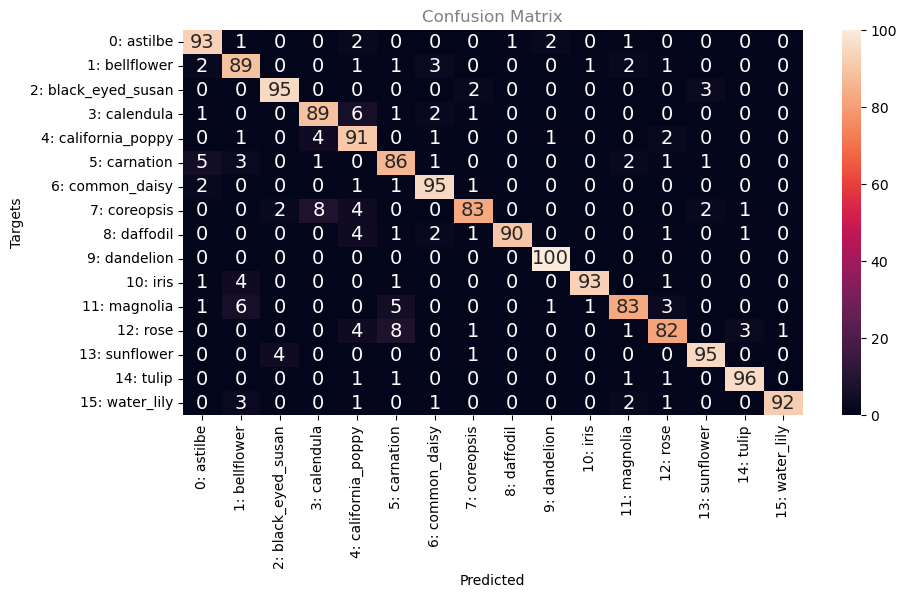

In [31]:
visualise_confusion_matrix(val_gt_labels, pred_indices)

In [33]:
from sklearn.metrics import classification_report

In [35]:
print(classification_report(val_gt_labels, pred_indices))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91       100
           1       0.83      0.89      0.86       100
           2       0.94      0.95      0.95       100
           3       0.87      0.89      0.88       100
           4       0.79      0.91      0.85       100
           5       0.82      0.86      0.84       100
           6       0.90      0.95      0.93       100
           7       0.92      0.83      0.87       100
           8       0.99      0.90      0.94       100
           9       0.96      1.00      0.98       100
          10       0.98      0.93      0.95       100
          11       0.90      0.83      0.86       100
          12       0.88      0.82      0.85       100
          13       0.94      0.95      0.95       100
          14       0.95      0.96      0.96       100
          15       0.99      0.92      0.95       100

    accuracy                           0.91      1600
   macro avg       0.91   